In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

import numpy as np
from scipy import sparse
from scipy.sparse import load_npz, hstack
from sklearn.preprocessing import StandardScaler, LabelEncoder
import sklearn.utils as sku

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [10]:
DATA_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_FILE = "Data_files/labels_nltk.txt"
SORT_FILE = "txt_files/multiclass_nltk_sort_idx.txt"

# Load
labels = np.genfromtxt(LABEL_FILE, delimiter=";", dtype=str, skip_header=1)
X = load_npz(DATA_FILE)
sort_idx = np.genfromtxt(SORT_FILE, dtype=int)

print("Loaded:", X.shape)

# Keep articles only
article_mask = np.abs(labels[:, 2].astype(int) - 1) == 0
X = X[article_mask]
labels = labels[article_mask]

print("After article filter:", X.shape)

# Add LIX score
lix = sparse.csr_matrix(labels[:, 0].astype(float).reshape(-1, 1))
X = hstack([lix, X], format="csr")

print("After LIX feature:", X.shape)

# Keep top 500 features
sort_idx = sort_idx[sort_idx < X.shape[1]]
X = X[:, sort_idx][:, :5000]

print("After feature selection:", X.shape)

# Scale
X = StandardScaler(with_mean=False).fit_transform(X)

print("After scaling:", X.shape)

# Keep top 10 topics
topics = labels[:, 1]

unique_topics, counts = np.unique(topics, return_counts=True)
top_topics = unique_topics[np.argsort(counts)[::-1][:10]]

mask = np.isin(topics, top_topics)

X = X[mask]
topics = topics[mask]

print("After top-10 topic filter:", X.shape)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(topics)

print("After label encoding:")
print("  X:", X.shape)
print("  y:", y.shape)

# Shuffle
X, y = sku.shuffle(X, y, random_state=5466542)

print("After shuffle:")
print("  X:", X.shape)
print("  y:", y.shape)

# Split
data_train, data_train_labels, \
data_val, data_val_labels, \
data_test, data_test_labels = bf.train_val_test_split(
    X, y,
    val_size=0.20,
    test_size=0.0
)

print("Train:", data_train.shape)
print("Val:  ", data_val.shape)
print("Test: ", data_test.shape)

Loaded: (780044, 64478)
After article filter: (775291, 64478)
After LIX feature: (775291, 64479)
After feature selection: (775291, 5000)
After scaling: (775291, 5000)
After top-10 topic filter: (434564, 5000)
After label encoding:
  X: (434564, 5000)
  y: (434564,)
After shuffle:
  X: (434564, 5000)
  y: (434564,)
Train: (347652, 5000)
Val:   (86912, 5000)
Test:  (0, 5000)


# Functions

In [11]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)
    
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

n_mult = 2

def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    Layer1 = trial.suggest_int("Layer1", 64, 256*n_mult)
    Layer2 = trial.suggest_int("Layer2", 32, 128*n_mult)
    Layer3 = trial.suggest_int("Layer3", 8, 64*n_mult)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    n_epochs = 10

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):
            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptModel().to(device)

    # --------------------------------------------------------
    # WEIGHTED CROSS ENTROPY LOSS
    # --------------------------------------------------------

    train_class_counts = np.bincount(
        data_train_labels.astype(int),
        minlength=num_classes
    )

    class_weights_np = len(data_train_labels) / (
        num_classes * train_class_counts
    )

    class_weights = pt.tensor(
        class_weights_np,
        dtype=pt.float32,
        device=device
    )

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    best_validation_loss = float("inf")

    for epoch in range(n_epochs):

        print(f"Trial {trial.number} | Optuna epoch {epoch + 1}/{n_epochs}")

        training_loss, validation_loss = Train(
            model_opt,
            optimizer,
            loss_function,
            train_loader,
            validation_loader,
            device,
            1
        )

        current_validation_loss = validation_loss[-1]

        best_validation_loss = min(
            best_validation_loss,
            current_validation_loss
        )

        trial.report(current_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

# HP optimization

In [ ]:
pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

study.optimize(
    objective,
    n_trials=30
)

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

[I 2026-06-07 17:22:23,081] A new study created in memory with name: no-name-7b3bb25e-8092-4f62-973b-a711acbe3387


Trial 0 | Optuna epoch 1/10


/var/folders/rp/p2_g6d3j74ggpl15kr0_k5zc0000gn/T/ipykernel_11303/1071056805.py:101: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()


EPOCH: 1 | training loss: 1.133  | validation loss: 0.933
Trial 0 | Optuna epoch 2/10
EPOCH: 1 | training loss: 0.923  | validation loss: 0.914
Trial 0 | Optuna epoch 3/10
EPOCH: 1 | training loss: 0.867  | validation loss: 0.912
Trial 0 | Optuna epoch 4/10
EPOCH: 1 | training loss: 0.821  | validation loss: 0.912
Trial 0 | Optuna epoch 5/10
EPOCH: 1 | training loss: 0.778  | validation loss: 0.917
Trial 0 | Optuna epoch 6/10
EPOCH: 1 | training loss: 0.737  | validation loss: 0.933
Trial 0 | Optuna epoch 7/10
EPOCH: 1 | training loss: 0.698  | validation loss: 0.945
Trial 0 | Optuna epoch 8/10
EPOCH: 1 | training loss: 0.662  | validation loss: 0.958
Trial 0 | Optuna epoch 9/10
EPOCH: 1 | training loss: 0.627  | validation loss: 0.973
Trial 0 | Optuna epoch 10/10


[I 2026-06-07 17:49:35,913] Trial 0 finished with value: 0.91182667748325 and parameters: {'learning_rate': 6.321348671641966e-05, 'batch_size': 32, 'Layer1': 189, 'Layer2': 172, 'Layer3': 125, 'dropout_rate': 0.2845327384518213}. Best is trial 0 with value: 0.91182667748325.


...

EPOCH: 1 | training loss: 0.983  | validation loss: 0.924
Trial 4 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.032  | validation loss: 0.909
Trial 4 | Optuna epoch 2/10
EPOCH: 1 | training loss: 0.831  | validation loss: 0.904
Trial 4 | Optuna epoch 3/10
EPOCH: 1 | training loss: 0.72  | validation loss: 0.921
Trial 4 | Optuna epoch 4/10
EPOCH: 1 | training loss: 0.596  | validation loss: 0.994
Trial 4 | Optuna epoch 5/10
EPOCH: 1 | training loss: 0.465  | validation loss: 1.122
Trial 4 | Optuna epoch 6/10
EPOCH: 1 | training loss: 0.363  | validation loss: 1.255
Trial 4 | Optuna epoch 7/10
EPOCH: 1 | training loss: 0.291  | validation loss: 1.514
Trial 4 | Optuna epoch 8/10
EPOCH: 1 | training loss: 0.247  | validation loss: 1.547
Trial 4 | Optuna epoch 9/10
EPOCH: 1 | training loss: 0.218  | validation loss: 1.689
Trial 4 | Optuna epoch 10/10


[I 2026-06-07 18:27:54,189] Trial 4 finished with value: 0.9039746407029906 and parameters: {'learning_rate': 0.00018065639855882487, 'batch_size': 128, 'Layer1': 476, 'Layer2': 111, 'Layer3': 104, 'dropout_rate': 0.1110802106130036}. Best is trial 4 with value: 0.9039746407029906.


EPOCH: 1 | training loss: 0.197  | validation loss: 1.71
Trial 5 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.957  | validation loss: 1.255
Trial 5 | Optuna epoch 2/10


[I 2026-06-07 18:35:38,193] Trial 5 pruned. 


EPOCH: 1 | training loss: 1.346  | validation loss: 1.047
Trial 6 | Optuna epoch 1/10
EPOCH: 1 | training loss: 1.099  | validation loss: 0.936
Trial 6 | Optuna epoch 2/10


In [ ]:
print(study.best_trial.params)

{'learning_rate': 0.000914399635278108, 'batch_size': 32, 'Layer1': 73, 'Layer2': 209, 'Layer3': 73, 'dropout_rate': 0.3223082406141146}


# Split data for actual training

In [ ]:
# --------------------------------------------------------
# SPLIT DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

# Split
data_train, data_train_labels, \
data_val, data_val_labels, \
data_test, data_test_labels = bf.train_val_test_split(
    X, y,
    val_size=0.20,
    test_size=0.10
)

# --------------------------------------------------------
# COMPUTE CLASS WEIGHTS FROM FINAL TRAIN SET
# --------------------------------------------------------

num_classes = len(label_encoder.classes_)

final_train_class_counts = np.bincount(
    data_train_labels.astype(int),
    minlength=num_classes
)

final_class_weights_np = len(data_train_labels) / (
    num_classes * final_train_class_counts
)

print("\nFinal training class counts and weights:")
for i, (count, weight) in enumerate(zip(final_train_class_counts, final_class_weights_np)):
    print(
        f"{label_encoder.classes_[i]:15s} "
        f"count={count:6d} "
        f"weight={weight:.3f}"
    )

# --------------------------------------------------------
# CREATE DATASETS
# --------------------------------------------------------

train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)
test_data = MyDataset(data_test, data_test_labels)


Final training class counts and weights:
Cykling         count=  9269 weight=3.282
Danmark         count= 87725 weight=0.347
Film og tv      count=  7319 weight=4.156
Fodbold         count= 19118 weight=1.591
Forbrug         count=  9011 weight=3.376
Internationalt  count= 85692 weight=0.355
Kultur          count= 19221 weight=1.583
Politik         count= 26362 weight=1.154
Sport           count= 20725 weight=1.468
Økonomi         count= 19754 weight=1.540


# Train the data with HP optimized parameters

In [ ]:
best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = best_params["dropout_rate"]

n_epochs = 5

input_dim = data_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Starting setup...")
print("Best hyperparameters:", best_params)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

class TopicModel(nn.Module):

    def __init__(self):
        super(TopicModel, self).__init__()

        self.input_layer = nn.Linear(input_dim, Layer1)
        self.hidden_layer1 = nn.Linear(Layer1, Layer2)
        self.hidden_layer2 = nn.Linear(Layer2, Layer3)
        self.output_layer = nn.Linear(Layer3, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, inputs):

        x = self.input_layer(inputs)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output_layer(x)

        return x

print("Selecting device...")
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

print("Creating model...")
model = TopicModel().to(device)
print("Model created.")

print("Creating optimizer...")
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
print("Optimizer created.")

print("Creating weighted loss function...")

class_weights = pt.tensor(
    final_class_weights_np,
    dtype=pt.float32,
    device=device
)

loss_function = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted loss function created.")

print("Class weights used:")
for i, weight in enumerate(class_weights.cpu().numpy()):
    print(
        f"{label_encoder.classes_[i]:15s} "
        f"weight={weight:.3f}"
    )

print("Creating data loaders...")
train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=sparse_collate
)

validation_loader = DataLoader(
    dataset=val_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

print("Data loaders created.")
print("Starting training...")

training_loss, validation_loss = Train(
    model,
    optimizer,
    loss_function,
    train_loader,
    validation_loader,
    device,
    n_epochs
)

print("Training finished.")
print("Training losses:")
print(training_loss)

print("Validation losses:")
print(validation_loss)

Starting setup...
Best hyperparameters: {'learning_rate': 0.000914399635278108, 'batch_size': 32, 'Layer1': 73, 'Layer2': 209, 'Layer3': 73, 'dropout_rate': 0.3223082406141146}
Input dimension: 500
Number of classes: 10
Selecting device...
Using device: cpu
Creating model...
Model created.
Creating optimizer...
Optimizer created.
Creating weighted loss function...
Weighted loss function created.
Class weights used:
Cykling         weight=3.282
Danmark         weight=0.347
Film og tv      weight=4.156
Fodbold         weight=1.591
Forbrug         weight=3.376
Internationalt  weight=0.355
Kultur          weight=1.583
Politik         weight=1.154
Sport           weight=1.468
Økonomi         weight=1.540
Creating data loaders...
Data loaders created.
Starting training...
EPOCH: 1 | training loss: 2.303  | validation loss: 2.302
EPOCH: 2 | training loss: 2.302  | validation loss: 2.301
EPOCH: 3 | training loss: 2.302  | validation loss: 2.304
EPOCH: 4 | training loss: 2.302  | validation los

# Plotting the results

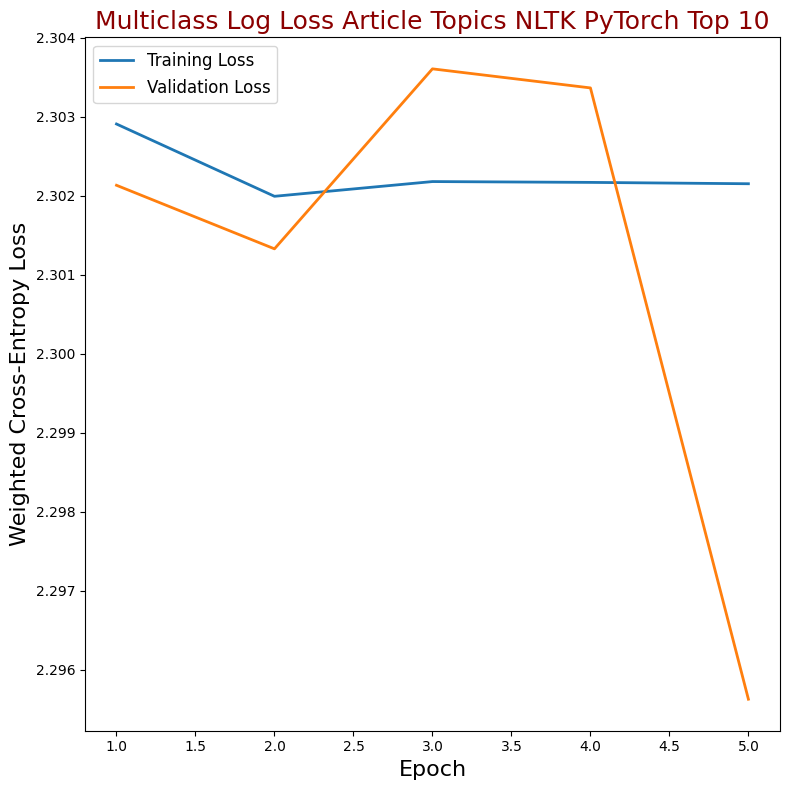


FINAL TEST RESULTS
Unweighted Cross-Entropy Loss : 2.2655
Sklearn Log Loss              : 2.2655
Accuracy                      : 0.3100
Macro F1                      : 0.0495
Weighted F1                   : 0.1499


In [ ]:
# --------------------------------------------------------
# PLOT TRAINING / VALIDATION LOG LOSS
# AND EVALUATE FINAL TEST PERFORMANCE
# --------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss
)

# --------------------------------------------------------
# LOSS CURVE
# --------------------------------------------------------

epochs = np.arange(
    1,
    len(training_loss) + 1
)

plt.figure(figsize=(8, 8))

plt.plot(
    epochs,
    training_loss,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Weighted Cross-Entropy Loss",
    fontsize=16
)

plt.title(
    "Multiclass Log Loss Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Multiclass_LogLoss_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# TEST SET EVALUATION
# --------------------------------------------------------

test_loader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

# Use unweighted cross-entropy for final test reporting
test_loss_function = nn.CrossEntropyLoss()

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

test_loss = 0.0
n_batches = 0

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device).long()

        outputs = model(input_batch)

        loss = test_loss_function(
            outputs,
            truth_batch
        )

        test_loss += loss.item()
        n_batches += 1

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

# --------------------------------------------------------
# FINAL METRICS
# --------------------------------------------------------

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

final_test_loss = test_loss / n_batches

final_log_loss = log_loss(
    all_truths,
    all_probabilities,
    labels=np.arange(num_classes)
)

test_accuracy = accuracy_score(
    all_truths,
    all_predictions
)

macro_f1 = f1_score(
    all_truths,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_truths,
    all_predictions,
    average="weighted"
)

# --------------------------------------------------------
# REPORT RESULTS
# --------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(
    f"Unweighted Cross-Entropy Loss : {final_test_loss:.4f}"
)

print(
    f"Sklearn Log Loss              : {final_log_loss:.4f}"
)

print(
    f"Accuracy                      : {test_accuracy:.4f}"
)

print(
    f"Macro F1                      : {macro_f1:.4f}"
)

print(
    f"Weighted F1                   : {weighted_f1:.4f}"
)

print("=" * 50)

Generating predictions...


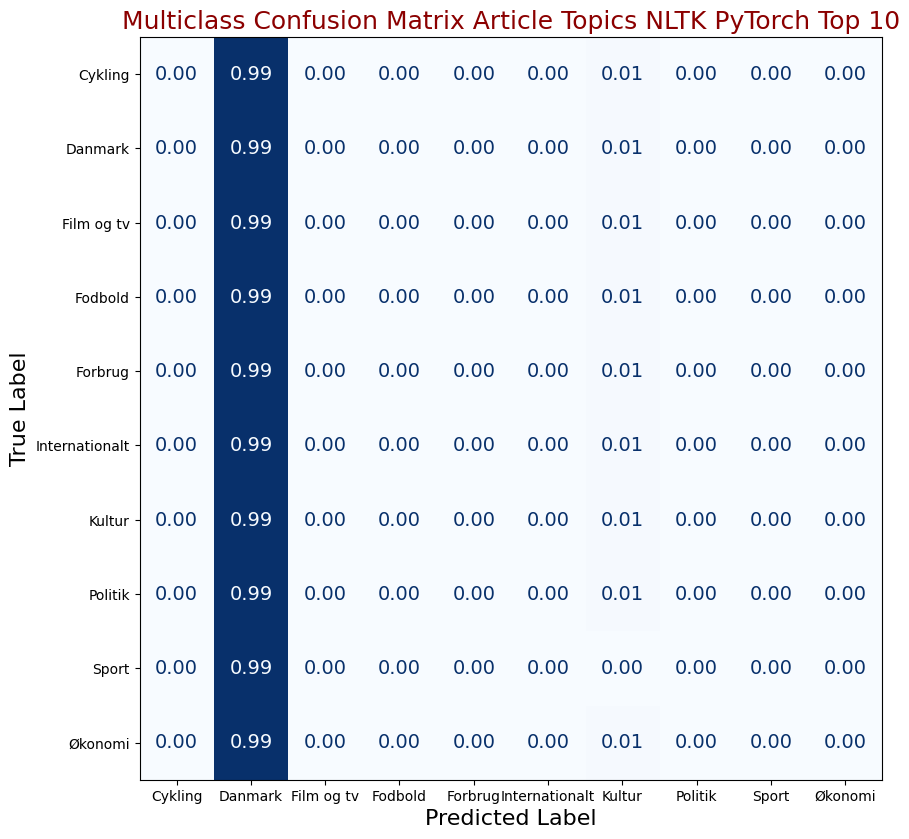

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PREDICTIONS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating predictions...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device).long()

        outputs = model(input_batch)

        predictions = pt.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

all_predictions = np.array(all_predictions).astype(int)
all_truths = np.array(all_truths).astype(int)

# --------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------------

cm = confusion_matrix(
    all_truths,
    all_predictions,
    labels=np.arange(num_classes),
    normalize="true"
)

cm = np.round(cm, 2)

classes = label_encoder.classes_

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=0,
    cmap=plt.cm.Blues,
    colorbar=False,
    values_format=".2f"
)

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "Multiclass Confusion Matrix Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)

plt.tight_layout()

plt.savefig(
    "Multiclass_ConfusionMatrix_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Generating prediction probabilities...


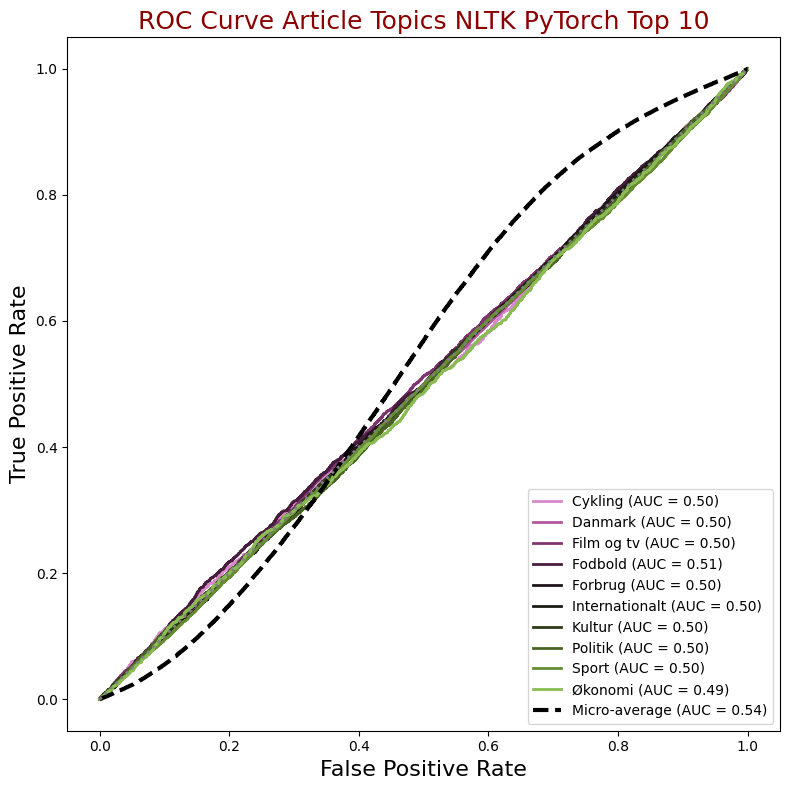

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET VALIDATION PROBABILITIES
# --------------------------------------------------------

model.eval()

all_probabilities = []
all_truths = []

classes = label_encoder.classes_
num_classes = len(classes)

print("Generating prediction probabilities...")

with pt.no_grad():

    for input_batch, truth_batch in validation_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device).long()

        outputs = model(input_batch)

        probabilities = pt.softmax(outputs, dim=1)

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_truths.extend(
            truth_batch.cpu().numpy()
        )

all_probabilities = np.array(all_probabilities)
all_truths = np.array(all_truths).astype(int)

# --------------------------------------------------------
# BINARIZE LABELS FOR MULTICLASS ROC
# --------------------------------------------------------

truths_binarized = label_binarize(
    all_truths,
    classes=np.arange(num_classes)
)

# --------------------------------------------------------
# COMPUTE ROC CURVES
# --------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        truths_binarized[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# --------------------------------------------------------
# MICRO-AVERAGE ROC
# --------------------------------------------------------

fpr["micro"], tpr["micro"], _ = roc_curve(
    truths_binarized.ravel(),
    all_probabilities.ravel()
)

roc_auc["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

# --------------------------------------------------------
# COLOR MAP
# --------------------------------------------------------

cmap = plt.get_cmap("vanimo")

colors = cmap(
    np.linspace(0.1, 0.9, num_classes)
)

# --------------------------------------------------------
# PLOT ROC CURVES
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for i, color in zip(range(num_classes), colors):

    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

ax.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    linewidth=3,
    label=f"Micro-average (AUC = {roc_auc['micro']:.2f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray"
)

plt.title(
    "ROC Curve Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)

plt.legend(
    fontsize=10,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "Multiclass_ROC_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()